## About this fork

Based on Tufa Labs’ Duck harness. This notebook selects MyAgent3Solver,
with an embedded solver and asynchronous model requests. Python tools and game
actions execute on one event-loop thread; concurrent games are limited to eight
by default, matching the vLLM sequence cap. Set MY_AGENT3_CONCURRENCY to tune it.
The model, runtime, and MTP serving configuration remain pinned.


# Tufa Labs ARC3 submission

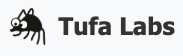

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# Skip periodic JSON/HTML diagnostics and per-frame logging for every run.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1"

# Apply the measured vLLM winner before any serving setup command runs.
PUBLIC25_VLLM_PROFILE_NAME = 'kv5-bf16-mtp3-c8-cg32'
PUBLIC25_VLLM_PROFILE_ENV = {
    "TAAF_VLLM_ENABLE_PREFIX_CACHING": "0",
    "TAAF_VLLM_KV_CACHE_DTYPE": "auto",
    "TAAF_VLLM_KV_CACHE_MEMORY_BYTES": "5368709120",
    "TAAF_VLLM_MAX_CUDAGRAPH_CAPTURE_SIZE": "32",
    "TAAF_VLLM_MAX_NUM_BATCHED_TOKENS": "8192",
    "TAAF_VLLM_MAX_NUM_SEQS": "8",
    "TAAF_VLLM_MTP_TOKENS": "3",
    "TAAF_VLLM_OMP_THREADS": "1"
}
for key, value in PUBLIC25_VLLM_PROFILE_ENV.items():
    os.environ[key] = value
print(
    f'PUBLIC25_VLLM_PROFILE name={PUBLIC25_VLLM_PROFILE_NAME} '
    f'env={json.dumps(PUBLIC25_VLLM_PROFILE_ENV, sort_keys=True)}',
    flush=True,
)
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
if not TRUE_SUBMISSION:
    for artifact in ("submission.parquet", "offline_validation.json"):
        (WORKING_DIR / artifact).unlink(missing_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["keithtyser/duck-qwen38-nvfp4-mtp-vllm-smoke-v1", "keithtyser/qwen38-flash-next-vllm-nvfp4-runtime-v1"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands â€” installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts â€” the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
from pathlib import Path
import importlib
import os
import sys

# Embed this checkout's solver so attached datasets cannot select stale code.
EMBEDDED_AGENT_SOURCE = '"""A Duck-style, Python-tool ARC-AGI-3 solver.\n\nUnlike :mod:`my_agent2`, this module does not ask the model to fill a fixed\nscene-analysis schema.  The model gets one ``python`` tool.  Every invocation\nreceives a compact view of the current board and transition history, and may\ncall ``action(...)`` from Python to inspect, experiment, or play a short,\nvalidated sequence.\n\nThis is intended for the Kaggle/TAAF runner.  It is deliberately standalone:\nthe normal ARC-AGI-3-Agents package does not depend on TAAF.\n"""\n\nfrom __future__ import annotations\n\nimport ast\nimport asyncio\nimport base64\nimport contextlib\nimport hashlib\nimport io\nimport json\nimport os\nimport sys\nimport time\nimport traceback\nfrom collections import Counter, defaultdict, deque\nfrom dataclasses import dataclass, field\nfrom pathlib import Path\nfrom typing import Any, Callable\n\nimport arcengine\nimport httpx\nimport numpy as np\nimport taaf.game\nfrom openai import (\n    APIConnectionError,\n    APIStatusError,\n    APITimeoutError,\n    AsyncOpenAI,\n    BadRequestError,\n)\nfrom PIL import Image\nfrom taaf.solver import Solver\n\nCOLOR_SYMBOLS = "0123456789ABCDEF"\nPALETTE = {\n    0: (255, 255, 255), 1: (204, 204, 204), 2: (153, 153, 153),\n    3: (102, 102, 102), 4: (51, 51, 51), 5: (0, 0, 0),\n    6: (229, 58, 163), 7: (255, 123, 204), 8: (249, 60, 49),\n    9: (30, 147, 255), 10: (136, 216, 241), 11: (255, 220, 0),\n    12: (255, 133, 27), 13: (146, 18, 49), 14: (79, 204, 48),\n    15: (163, 86, 214),\n}\n\nPYTHON_TOOL = {\n    "type": "function",\n    "function": {\n        "name": "python",\n        "description": (\n            "Run a short Python program against the current game state. "\n            "Use action([...]) inside code to execute real, legal game actions."\n        ),\n        "parameters": {\n            "type": "object",\n            "properties": {"code": {"type": "string"}},\n            "required": ["code"],\n            "additionalProperties": False,\n        },\n    },\n}\n\n\ndef _env_int(name: str, default: int, minimum: int = 1) -> int:\n    try:\n        return max(minimum, int(os.getenv(name, default)))\n    except ValueError:\n        return default\n\n\ndef _env_bool(name: str, default: bool = False) -> bool:\n    value = os.getenv(name)\n    if value is None:\n        return default\n    return value.strip().lower() in {"1", "true", "yes", "on"}\n\n\ndef _env_float(name: str, default: float, minimum: float = 0.0) -> float:\n    try:\n        return max(minimum, float(os.getenv(name, default)))\n    except ValueError:\n        return default\n\n\nclass RunLogger:\n    """Structured run log, enabled by default outside competition reruns."""\n\n    def __init__(self, game: Any) -> None:\n        # Development runs need their model-error chronology to be useful.  Keep\n        # competition reruns quiet by default, while allowing either mode to be\n        # overridden explicitly with MY_AGENT3_LOG_DIR (an empty value disables it).\n        root = os.getenv("MY_AGENT3_LOG_DIR")\n        if root is None and not _env_bool("TAAF_RUN_AS_SUBMISSION"):\n            kaggle_working = Path("/kaggle/working")\n            root = str(kaggle_working / "my_agent3_logs") if kaggle_working.is_dir() else "my_agent3_logs"\n        self.file: Any | None = None\n        self.include_boards = _env_bool("MY_AGENT3_LOG_BOARDS")\n        self.stdout = _env_bool("MY_AGENT3_LOG_STDOUT")\n        if not root:\n            return\n        game_id = str(\n            getattr(game, "game_id", None) or getattr(game, "env_name", None) or "unknown"\n        )\n        safe_game_id = "".join(char if char.isalnum() or char in "-_." else "_" for char in game_id)\n        directory = Path(root)\n        directory.mkdir(parents=True, exist_ok=True)\n        self.file = (directory / f"{safe_game_id}.{int(time.time() * 1000)}.jsonl").open(\n            "a", encoding="utf-8"\n        )\n        self.record("run_started", game_id=game_id)\n\n    def record(self, event: str, **data: Any) -> None:\n        payload = {"timestamp": time.time(), "event": event, **data}\n        if self.file is not None:\n            self.file.write(json.dumps(payload, default=str, separators=(",", ":")) + "\\n")\n            self.file.flush()\n        if self.stdout:\n            preview = json.dumps(payload, default=str)[:2_000]\n            # Python tool code is run under redirect_stdout().  Mirrored\n            # diagnostics must not become accidental, often huge, model tool\n            # output; keep them on the original process stream instead.\n            print(f"[MYAGENT3 {event}] {preview}", file=sys.__stdout__, flush=True)\n\n    def board(self, event: str, frame: "FrameView") -> None:\n        payload: dict[str, Any] = {\n            "shape": frame.shape,\n            "level": frame.level,\n            "step": frame.step,\n            "component_count": len(frame.segmentation["nodes"]),\n        }\n        if self.include_boards:\n            payload["ascii"] = frame.ascii\n            payload["segmentation"] = frame.segmentation\n        self.record(event, **payload)\n\n    def close(self) -> None:\n        if self.file is not None:\n            self.record("run_finished")\n            self.file.close()\n            self.file = None\n\n\ndef _game_action(value: Any) -> arcengine.GameAction:\n    """Resolve an enum, numeric id, or action name without accepting aliases."""\n    if isinstance(value, arcengine.GameAction):\n        return value\n    if isinstance(value, int):\n        return arcengine.GameAction.from_id(value)\n    if isinstance(value, str):\n        name = value.upper().strip()\n        if name == "MOUSE":\n            name = "ACTION6"\n        try:\n            return arcengine.GameAction.from_name(name)\n        except (AttributeError, KeyError, ValueError):\n            return arcengine.GameAction.from_id(int(name))\n    raise TypeError(f"Unsupported action value: {value!r}")\n\n\ndef _action_name(value: Any) -> str:\n    try:\n        return _game_action(value).name\n    except (TypeError, ValueError):\n        return str(value)\n\n\ndef _board_from_state(state: Any) -> np.ndarray:\n    board = np.asarray(state.frame.data, dtype=np.int16)\n    # TAAF currently supplies a 2-D board.  This makes an accidental leading\n    # animation/frame dimension harmless rather than silently flattening it.\n    if board.ndim == 3:\n        board = board[-1]\n    if board.ndim != 2:\n        raise ValueError(f"Expected a 2-D game board, received shape {board.shape}")\n    return board\n\n\ndef _ascii(board: np.ndarray) -> str:\n    return "\\n".join(\n        "".join(COLOR_SYMBOLS[int(cell)] if 0 <= int(cell) < 16 else "?" for cell in row)\n        for row in board\n    )\n\n\ndef _image_url(board: np.ndarray) -> str:\n    height, width = board.shape\n    rgb = np.zeros((height, width, 3), dtype=np.uint8)\n    for color, value in PALETTE.items():\n        rgb[board == color] = value\n    # A 64px board loses object detail in many VLM preprocessors.\n    image = Image.fromarray(rgb).resize((width * 8, height * 8), Image.Resampling.NEAREST)\n    buffer = io.BytesIO()\n    image.save(buffer, format="PNG")\n    return "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")\n\n\ndef _components(board: np.ndarray) -> dict[str, Any]:\n    """Return compact components in O(board area), with bounded containment."""\n    height, width = board.shape\n    labels = np.full((height, width), -1, dtype=np.int32)\n    nodes: list[dict[str, Any]] = []\n    for row in range(height):\n        for col in range(width):\n            if labels[row, col] >= 0:\n                continue\n            color = int(board[row, col])\n            queue = deque([(row, col)])\n            component_id = len(nodes)\n            labels[row, col] = component_id\n            pixels: set[tuple[int, int]] = set()\n            ordered_pixels: list[tuple[int, int]] = []\n            min_y = max_y = row\n            min_x = max_x = col\n            while queue:\n                y, x = queue.popleft()\n                pixels.add((y, x))\n                ordered_pixels.append((y, x))\n                min_y, max_y = min(min_y, y), max(max_y, y)\n                min_x, max_x = min(min_x, x), max(max_x, x)\n                for ny, nx in ((y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)):\n                    if (\n                        0 <= ny < height and 0 <= nx < width\n                        and labels[ny, nx] < 0 and int(board[ny, nx]) == color\n                    ):\n                        labels[ny, nx] = component_id\n                        queue.append((ny, nx))\n            # BFS starts at the component\'s top-left-most cell and has a fixed\n            # neighbour order, so ordered_pixels is a deterministic shape key\n            # without an O(component_size log component_size) sort.\n            normal = [(y - min_y, x - min_x) for y, x in ordered_pixels]\n            digest = hashlib.sha1(repr((color, normal)).encode()).hexdigest()[:12]\n            boundary = [\n                (y, x) for y, x in pixels\n                if any((y + dy, x + dx) not in pixels for dy, dx in ((-1, 0), (1, 0), (0, -1), (0, 1)))\n            ]\n            nodes.append({\n                "id": len(nodes), "color": COLOR_SYMBOLS[color] if 0 <= color < 16 else "?",\n                "color_id": color, "hash": digest, "pixels": len(pixels),\n                "bbox": [min_y, min_x, max_y, max_x], "boundary": boundary[:128], "children": [],\n            })\n\n    # Every adjacent component pair appears on a horizontal or vertical grid\n    # edge.  Scanning those edges avoids comparing every pair of objects.\n    adjacency: set[tuple[int, int]] = set()\n    for left, right in ((labels[:, :-1], labels[:, 1:]), (labels[:-1, :], labels[1:, :])):\n        changed = left != right\n        for first, second in zip(left[changed].tolist(), right[changed].tolist()):\n            adjacency.add((min(first, second), max(first, second)))\n\n    # Bounding-box containment is useful for small object scenes, but an O(n²)\n    # relation is not acceptable for highly fragmented boards.  It is omitted\n    # above this cap rather than delaying the first inference request.\n    containment_cap = _env_int("MY_AGENT3_MAX_CONTAINMENT_NODES", 128)\n    containment_truncated = len(nodes) > containment_cap\n    if not containment_truncated:\n        for child in nodes:\n            y1, x1, y2, x2 = child["bbox"]\n            containers = []\n            for parent in nodes:\n                if parent["id"] == child["id"]:\n                    continue\n                py1, px1, py2, px2 = parent["bbox"]\n                if py1 <= y1 and px1 <= x1 and py2 >= y2 and px2 >= x2:\n                    containers.append(parent)\n            if containers:\n                parent = min(containers, key=lambda item: item["pixels"])\n                parent["children"].append(child["id"])\n    return {\n        "nodes": nodes,\n        "adjacency_list": [list(edge) for edge in sorted(adjacency)],\n        "containment_truncated": containment_truncated,\n    }\n\n\ndef _component_brief(node: dict[str, Any]) -> dict[str, Any]:\n    return {\n        key: node[key]\n        for key in ("id", "color", "pixels", "bbox", "hash")\n    }\n\n\ndef _bbox_distance(left: dict[str, Any], right: dict[str, Any]) -> int:\n    """Manhattan distance between component bounding-box centres, in grid cells."""\n    ly1, lx1, ly2, lx2 = left["bbox"]\n    ry1, rx1, ry2, rx2 = right["bbox"]\n    return abs((ly1 + ly2) - (ry1 + ry2)) + abs((lx1 + lx2) - (rx1 + rx2))\n\n\ndef _transition_summary(\n    before_board: np.ndarray,\n    after_board: np.ndarray,\n    before_segmentation: dict[str, Any],\n    after_segmentation: dict[str, Any],\n) -> dict[str, Any]:\n    """Describe a transition compactly enough to be useful in a tool response."""\n    changed = before_board != after_board\n    coordinates = np.argwhere(changed)\n    changed_count = int(len(coordinates))\n    cell_summary: dict[str, Any] = {"count": changed_count}\n    if changed_count:\n        min_y, min_x = coordinates.min(axis=0).tolist()\n        max_y, max_x = coordinates.max(axis=0).tolist()\n        cell_summary["bbox"] = [int(min_y), int(min_x), int(max_y), int(max_x)]\n        color_changes = Counter(\n            (int(before_board[y, x]), int(after_board[y, x]))\n            for y, x in coordinates\n        )\n        cell_summary["color_changes"] = [\n            {\n                "from": COLOR_SYMBOLS[before] if 0 <= before < len(COLOR_SYMBOLS) else "?",\n                "to": COLOR_SYMBOLS[after] if 0 <= after < len(COLOR_SYMBOLS) else "?",\n                "cells": count,\n            }\n            for (before, after), count in color_changes.most_common(12)\n        ]\n        sample_cap = _env_int("MY_AGENT3_CHANGE_CELL_SAMPLES", 24)\n        cell_summary["samples"] = [\n            {\n                "row": int(y), "col": int(x),\n                "from": COLOR_SYMBOLS[int(before_board[y, x])],\n                "to": COLOR_SYMBOLS[int(after_board[y, x])],\n            }\n            for y, x in coordinates[:sample_cap]\n        ]\n\n    before_nodes = before_segmentation["nodes"]\n    after_nodes = after_segmentation["nodes"]\n    tracking_cap = _env_int("MY_AGENT3_MAX_TRACKED_COMPONENTS", 256)\n    tracking_truncated = len(before_nodes) > tracking_cap or len(after_nodes) > tracking_cap\n    moved: list[dict[str, Any]] = []\n    appeared: list[dict[str, Any]] = []\n    disappeared: list[dict[str, Any]] = []\n    if not tracking_truncated:\n        # A colour/shape/pixel-count match is a conservative identity cue.  It\n        # handles translated players without pretending that local node ids are\n        # persistent.  Ambiguous duplicates are paired by nearest position.\n        before_groups: dict[tuple[int, str, int], list[dict[str, Any]]] = defaultdict(list)\n        after_groups: dict[tuple[int, str, int], list[dict[str, Any]]] = defaultdict(list)\n        for node in before_nodes:\n            before_groups[(node["color_id"], node["hash"], node["pixels"])].append(node)\n        for node in after_nodes:\n            after_groups[(node["color_id"], node["hash"], node["pixels"])].append(node)\n\n        unmatched_before = {node["id"] for node in before_nodes}\n        unmatched_after = {node["id"] for node in after_nodes}\n        before_by_id = {node["id"]: node for node in before_nodes}\n        after_by_id = {node["id"]: node for node in after_nodes}\n        for signature, prior_nodes in before_groups.items():\n            remaining = list(after_groups.get(signature, []))\n            for prior in prior_nodes:\n                if not remaining:\n                    break\n                current = min(remaining, key=lambda node: _bbox_distance(prior, node))\n                remaining.remove(current)\n                unmatched_before.discard(prior["id"])\n                unmatched_after.discard(current["id"])\n                before_bbox, after_bbox = prior["bbox"], current["bbox"]\n                row_delta = int(after_bbox[0] - before_bbox[0])\n                col_delta = int(after_bbox[1] - before_bbox[1])\n                if row_delta or col_delta:\n                    moved.append({\n                        "before_id": prior["id"], "after_id": current["id"],\n                        "color": prior["color"], "pixels": prior["pixels"], "hash": prior["hash"],\n                        "before_bbox": before_bbox, "after_bbox": after_bbox,\n                        "row_delta": row_delta, "col_delta": col_delta,\n                        "row_delta_note": "negative is up; positive is down",\n                        "col_delta_note": "negative is left; positive is right",\n                    })\n        component_cap = _env_int("MY_AGENT3_COMPONENT_CHANGE_SAMPLES", 16)\n        appeared = [_component_brief(after_by_id[node_id]) for node_id in sorted(unmatched_after)[:component_cap]]\n        disappeared = [_component_brief(before_by_id[node_id]) for node_id in sorted(unmatched_before)[:component_cap]]\n\n    return {\n        "cells": cell_summary,\n        "moved_components": moved[:_env_int("MY_AGENT3_MOVEMENT_SAMPLES", 16)],\n        "appeared_components": appeared,\n        "disappeared_components": disappeared,\n        "tracking_truncated": tracking_truncated,\n    }\n\n\ndef _region_array(\n    board: np.ndarray, row: int, col: int, height: int, width: int,\n) -> np.ndarray:\n    """Validate and extract a deliberately small board crop."""\n    if any(isinstance(value, bool) or not isinstance(value, int) for value in (row, col, height, width)):\n        raise TypeError("row, col, height, and width must be integers")\n    if height <= 0 or width <= 0:\n        raise ValueError("height and width must be positive")\n    if height * width > _env_int("MY_AGENT3_MAX_REGION_CELLS", 400):\n        raise ValueError("requested region exceeds MY_AGENT3_MAX_REGION_CELLS")\n    end_row, end_col = row + height, col + width\n    if row < 0 or col < 0 or end_row > board.shape[0] or end_col > board.shape[1]:\n        raise ValueError(f"region [{row}:{end_row}, {col}:{end_col}] is outside board {board.shape}")\n    return board[row:end_row, col:end_col]\n\n\ndef _region_view(board: np.ndarray, row: int, col: int, height: int, width: int) -> dict[str, Any]:\n    region = _region_array(board, row, col, height, width)\n    return {\n        "bbox": [row, col, row + height - 1, col + width - 1],\n        "shape": [height, width],\n        "row_labels": list(range(row, row + height)),\n        "column_labels": list(range(col, col + width)),\n        "ascii": _ascii(region),\n    }\n\n\ndef _clamped_region_view(\n    board: np.ndarray, row: int, col: int, height: int, width: int,\n) -> dict[str, Any]:\n    """Return the requested view after clipping it to board and output limits."""\n    if any(isinstance(value, bool) or not isinstance(value, int) for value in (row, col, height, width)):\n        raise TypeError("row, col, height, and width must be integers")\n    if height <= 0 or width <= 0:\n        raise ValueError("height and width must be positive")\n    requested = {"row": row, "col": col, "height": height, "width": width}\n    max_cells = _env_int("MY_AGENT3_MAX_REGION_CELLS", 400)\n    height, width = min(height, board.shape[0]), min(width, board.shape[1])\n    if height * width > max_cells:\n        aspect = width / height\n        height = max(1, min(height, int((max_cells / aspect) ** 0.5)))\n        width = max(1, min(width, max_cells // height))\n    top = min(max(row, 0), board.shape[0] - height)\n    left = min(max(col, 0), board.shape[1] - width)\n    view = _region_view(board, top, left, height, width)\n    view["requested"] = requested\n    view["clamped"] = requested != {\n        "row": top, "col": left, "height": height, "width": width,\n    }\n    return view\n\n\n@dataclass\nclass EdgeSignalTracker:\n    """Learn when a long, thin edge component behaves like a HUD indicator.\n\n    An edge location is ignored for state fingerprints only after its component\n    count changes monotonically for several actions. Touching an edge alone\n    never makes a region a HUD.\n    """\n\n    candidates: dict[tuple[int, int, int, int, str], dict[str, Any]] = field(default_factory=dict)\n    min_progress_steps: int = field(\n        default_factory=lambda: _env_int("MY_AGENT3_HUD_CONFIRM_STEPS", 3)\n    )\n\n    @staticmethod\n    def _discover(frame: FrameView) -> dict[tuple[int, int, int, int, str], dict[str, Any]]:\n        height, width = frame.shape\n        found = {}\n        for node in frame.segmentation["nodes"]:\n            r1, c1, r2, c2 = map(int, node["bbox"])\n            box_height, box_width = r2 - r1 + 1, c2 - c1 + 1\n            horizontal = box_height <= 4 and box_width >= max(8, width // 4)\n            vertical = box_width <= 4 and box_height >= max(8, height // 4)\n            touches_edge = r1 == 0 or c1 == 0 or r2 == height - 1 or c2 == width - 1\n            if touches_edge and (horizontal or vertical):\n                key = (r1, c1, r2, c2, str(node["color"]))\n                found[key] = {"bbox": [r1, c1, r2, c2], "color": str(node["color"])}\n        return found\n\n    @staticmethod\n    def _count(frame: FrameView, bbox: list[int], color: str) -> int:\n        r1, c1, r2, c2 = bbox\n        rows = frame.ascii.splitlines()\n        return sum(row[c1:c2 + 1].count(color) for row in rows[r1:r2 + 1])\n\n    def observe(\n        self, before: FrameView, after: FrameView, summary: dict[str, Any],\n        tracked_entity_visible: bool = False,\n    ) -> dict[str, Any]:\n        for key, candidate in self._discover(before).items():\n            self.candidates.setdefault(key, {\n                **candidate, "progress_steps": 0, "last_direction": 0,\n                "verified": False, "observations": 0, "nonmoving_indicator_observations": 0,\n            })\n        changed_bbox = (summary.get("cells") or {}).get("bbox")\n        changed = bool((summary.get("cells") or {}).get("count", 0))\n        for candidate in self.candidates.values():\n            old_count = self._count(before, candidate["bbox"], candidate["color"])\n            new_count = self._count(after, candidate["bbox"], candidate["color"])\n            delta = new_count - old_count\n            if not delta:\n                continue\n            candidate["observations"] += 1\n            direction = 1 if delta > 0 else -1\n            candidate["progress_steps"] = (\n                candidate["progress_steps"] + 1\n                if candidate["last_direction"] == direction else 1\n            )\n            candidate["last_direction"] = direction\n        hud_only = False\n        if changed and changed_bbox:\n            cr1, cc1, cr2, cc2 = changed_bbox\n            for candidate in self.candidates.values():\n                r1, c1, r2, c2 = candidate["bbox"]\n                inside = r1 <= cr1 <= cr2 <= r2 and c1 <= cc1 <= cc2 <= c2\n                if inside and not summary.get("moved_components") and tracked_entity_visible:\n                    candidate["nonmoving_indicator_observations"] += 1\n                    if (\n                        candidate["progress_steps"] >= self.min_progress_steps\n                        and candidate["nonmoving_indicator_observations"] >= 2\n                    ):\n                        candidate["verified"] = True\n                if candidate["verified"] and inside and not summary.get("moved_components"):\n                    hud_only = True\n                    break\n        return {\n            "classification": "likely_hud_only" if hud_only else "gameplay_or_uncertain",\n            "gameplay_changed": bool(changed and not hud_only),\n            "candidate_indicators": [dict(value) for value in self.candidates.values()],\n        }\n\n    def ignored_regions(self) -> list[list[int]]:\n        return [value["bbox"] for value in self.candidates.values() if value["verified"]]\n\n\n\n\ndef _relative_pattern_mismatches(first: np.ndarray, second: np.ndarray) -> int:\n    """Compare equality structure while allowing a consistent colour remap."""\n    first_to_second: dict[int, int] = {}\n    second_to_first: dict[int, int] = {}\n    mismatches = 0\n    for left, right in zip(first.flat, second.flat):\n        left_id, right_id = int(left), int(right)\n        if (\n            left_id in first_to_second and first_to_second[left_id] != right_id\n        ) or (\n            right_id in second_to_first and second_to_first[right_id] != left_id\n        ):\n            mismatches += 1\n            continue\n        first_to_second[left_id] = right_id\n        second_to_first[right_id] = left_id\n    return mismatches\n\n\ndef _compare_regions(\n    board: np.ndarray,\n    row1: int,\n    col1: int,\n    row2: int,\n    col2: int,\n    height: int,\n    width: int,\n    rotations: bool = True,\n    reflections: bool = True,\n) -> dict[str, Any]:\n    """Compare two crops under exact and colour-remapped pattern matching."""\n    first = _region_array(board, row1, col1, height, width)\n    second = _region_array(board, row2, col2, height, width)\n    variants: list[tuple[str, np.ndarray]] = [("identity", second)]\n    if rotations:\n        variants.extend((f"rotate_{degrees}", np.rot90(second, turns)) for turns, degrees in ((1, 90), (2, 180), (3, 270)))\n    if reflections:\n        variants.append(("flip_left_right", np.fliplr(second)))\n        variants.append(("flip_up_down", np.flipud(second)))\n    if rotations and reflections:\n        variants.extend(\n            (f"rotate_{degrees}_flip_left_right", np.fliplr(np.rot90(second, turns)))\n            for turns, degrees in ((1, 90), (2, 180), (3, 270))\n        )\n\n    exact_options: list[tuple[int, str]] = []\n    relative_options: list[tuple[int, str]] = []\n    for name, candidate in variants:\n        if candidate.shape != first.shape:\n            continue\n        exact_options.append((int(np.count_nonzero(first != candidate)), name))\n        relative_options.append((_relative_pattern_mismatches(first, candidate), name))\n    if not exact_options:\n        raise ValueError("no requested transform preserves the region dimensions")\n    exact_mismatches, exact_transform = min(exact_options)\n    relative_mismatches, relative_transform = min(relative_options)\n    cells = int(first.size)\n    return {\n        "first": _region_view(board, row1, col1, height, width),\n        "second": _region_view(board, row2, col2, height, width),\n        "exact": {\n            "best_transform": exact_transform,\n            "matching_cells": cells - exact_mismatches,\n            "mismatched_cells": exact_mismatches,\n            "equal": exact_mismatches == 0,\n        },\n        "relative_pattern": {\n            "best_transform": relative_transform,\n            "matching_cells": cells - relative_mismatches,\n            "mismatched_cells": relative_mismatches,\n            "equal": relative_mismatches == 0,\n            "meaning": "same equality pattern with a consistent colour remap",\n        },\n    }\n\n\ndef _compact_transition_result(result: dict[str, Any]) -> dict[str, Any]:\n    """Keep a fresh turn informative without replaying verbose tool output."""\n    summary = result.get("change_summary") or {}\n    cells = summary.get("cells") or {}\n    prediction_check = result.get("prediction_check")\n    return {\n        key: result.get(key)\n        for key in (\n            "action", "board_changed", "gameplay_changed", "hud_assessment",\n            "level_completed", "game_over", "done", "valid_actions", "actions_taken",\n        )\n    } | {\n        "change": {\n            "cells": {key: cells[key] for key in ("count", "bbox", "color_changes") if key in cells},\n            "moved_components": [\n                {\n                    key: component[key]\n                    for key in (\n                        "color", "pixels", "hash", "before_bbox", "after_bbox", "row_delta", "col_delta",\n                    )\n                    if key in component\n                }\n                for component in summary.get("moved_components", [])\n            ],\n            "appeared_count": len(summary.get("appeared_components", [])),\n            "disappeared_count": len(summary.get("disappeared_components", [])),\n            "tracking_truncated": summary.get("tracking_truncated", False),\n        },\n    } | (\n        {"prediction_check": {\n            key: prediction_check.get(key)\n            for key in ("action", "expected", "matched", "observed")\n        }}\n        if prediction_check is not None else {}\n    )\n\n\ndef _repair_trailing_tool_artifact(code: str) -> str | None:\n    """Repair only the recurring unmatched ``},`` suffix emitted by some servers."""\n    stripped = code.rstrip()\n    for suffix in ("},", "}"):\n        if not stripped.endswith(suffix):\n            continue\n        repaired = stripped[: -len(suffix)].rstrip()\n        if repaired.endswith(")"):\n            return repaired\n    return None\n\ndef _uses_direct_ascii(code: str) -> bool:\n    """Reject unbounded board-string access from model-authored code."""\n    try:\n        tree = ast.parse(code)\n    except SyntaxError:\n        return False\n    return any(\n        (isinstance(node, ast.Attribute) and node.attr == "ascii")\n        or (\n            isinstance(node, ast.Call)\n            and isinstance(node.func, ast.Name)\n            and node.func.id == "getattr"\n            and len(node.args) >= 2\n            and isinstance(node.args[1], ast.Constant)\n            and node.args[1].value == "ascii"\n        )\n        for node in ast.walk(tree)\n\n    )\n\n\n\ndef _motion_member_key(component: dict[str, Any]) -> tuple[str, int, str]:\n    """Stable-enough identifier for a shape-preserving translated component."""\n    return (\n        str(component["color"]),\n        int(component["pixels"]),\n        str(component.get("hash", "")),\n    )\n\n\ndef _motion_member_brief(member: tuple[str, int, str]) -> dict[str, Any]:\n    color, pixels, shape_hash = member\n    return {"color": color, "pixels": pixels, "hash": shape_hash}\n\n\n@dataclass\nclass MotionHypothesisTracker:\n    """Accumulate conservative, action-dependent translation hypotheses.\n\n    Component ids belong to one segmentation only, so they cannot be used as\n    tracks.  Instead we use the existing exact colour/shape/pixel match from a\n    transition summary.  This intentionally excludes components that merely\n    grow, shrink, appear, or disappear (for example, a progress indicator).\n    """\n\n    max_candidates: int = field(\n        default_factory=lambda: _env_int("MY_AGENT3_MAX_MOTION_HYPOTHESES", 64)\n    )\n    action_trials: Counter[str] = field(default_factory=Counter)\n    candidate_trials: dict[tuple[tuple[str, int, str], ...], Counter[str]] = field(\n        default_factory=dict\n    )\n    candidates: dict[tuple[tuple[str, int, str], ...], Counter[tuple[str, int, int]]] = field(\n        default_factory=dict\n    )\n    non_translation_effects: dict[tuple[tuple[str, int, str], ...], Counter[str]] = field(\n        default_factory=dict\n    )\n    non_translation_examples: dict[\n        tuple[tuple[str, int, str], ...], dict[str, list[dict[str, Any]]]\n    ] = field(default_factory=dict)\n\n    def observe(\n        self,\n        action: str,\n        transition: dict[str, Any],\n        before_segmentation: dict[str, Any],\n    ) -> None:\n        """Record every exact translation and the co-moving groups it implies."""\n        self.action_trials[action] += 1\n        if transition.get("tracking_truncated"):\n            return\n\n        groups: dict[tuple[int, int], list[dict[str, Any]]] = defaultdict(list)\n        for component in transition.get("moved_components", []):\n            row_delta = component.get("row_delta")\n            col_delta = component.get("col_delta")\n            if not isinstance(row_delta, int) or not isinstance(col_delta, int):\n                continue\n            if not (row_delta or col_delta):\n                continue\n            groups[(row_delta, col_delta)].append(component)\n\n        moved_members = {\n            _motion_member_key(component)\n            for components in groups.values()\n            for component in components\n        }\n        visible_nodes: dict[tuple[str, int, str], list[dict[str, Any]]] = defaultdict(list)\n        for node in before_segmentation["nodes"]:\n            visible_nodes[_motion_member_key(node)].append(node)\n\n        # A learned candidate that is visible before an action but does not\n        # translate afterwards is valuable route evidence.  It may mean a wall,\n        # a boundary, or a conditional control, so do not overstate it as a\n        # definite collision.  This is deliberately evaluated before adding\n        # candidates from the current action.\n        for members in self.candidates:\n            if not all(visible_nodes.get(member) for member in members):\n                continue\n            self.candidate_trials.setdefault(members, Counter())[action] += 1\n            if any(member in moved_members for member in members):\n                continue\n            effects = self.non_translation_effects.setdefault(members, Counter())\n            effects[action] += 1\n            examples = self.non_translation_examples.setdefault(members, {})\n            examples[action] = [\n                {\n                    "color": node["color"],\n                    "pixels": node["pixels"],\n                    "bbox": node["bbox"],\n                }\n                for member in members\n                for node in visible_nodes[member][:1]\n            ]\n\n        # Store both each part and a group when several parts move together.\n        # A group can represent a multicolour player without assuming that one\n        # particular colour is the entity\'s "real" identity.\n        for (row_delta, col_delta), components in groups.items():\n            member_groups = [\n                (member,)\n                for member in (_motion_member_key(component) for component in components)\n            ]\n            if len(components) > 1:\n                member_groups.append(tuple(sorted(_motion_member_key(component) for component in components)))\n            for members in member_groups:\n                if members not in self.candidates and len(self.candidates) >= self.max_candidates:\n                    continue\n                is_new_candidate = members not in self.candidates\n                effects = self.candidates.setdefault(members, Counter())\n                if is_new_candidate:\n                    self.candidate_trials.setdefault(members, Counter())[action] += 1\n                effects[(action, row_delta, col_delta)] += 1\n\n    def snapshot(self) -> dict[str, Any]:\n        """Return compact evidence, ranked without claiming certainty too early."""\n        candidates: list[dict[str, Any]] = []\n        for members, effects in self.candidates.items():\n            action_effects = []\n            total_support = 0\n            for action in sorted({action for action, _, _ in effects}):\n                options = [\n                    (count, row_delta, col_delta)\n                    for (effect_action, row_delta, col_delta), count in effects.items()\n                    if effect_action == action\n                ]\n                support, row_delta, col_delta = max(options)\n                total_support += support\n                trials = self.candidate_trials.get(members, Counter())[action]\n                consistency = support / trials if trials else 0.0\n                # One observation is useful but not proof; repeated, consistent\n                # probes asymptotically approach 1.0.\n                confidence = consistency * support / (support + 1)\n                action_effects.append({\n                    "action": action,\n                    "row_delta": row_delta,\n                    "col_delta": col_delta,\n                    "observations": support,\n                    "action_trials": trials,\n                    "confidence": round(confidence, 2),\n                })\n            candidate_confidence = max(\n                (effect["confidence"] for effect in action_effects), default=0.0\n            )\n            member_label = "+".join(\n                f"{color}{pixels}:{shape_hash[:6]}"\n                for color, pixels, shape_hash in members\n            )\n            candidates.append({\n                "candidate_id": (\n                    f"group:{member_label}" if len(members) > 1 else f"component:{member_label}"\n                ),\n                "kind": "co_moving_group" if len(members) > 1 else "component",\n                "members": [_motion_member_brief(member) for member in members],\n                "translation_observations": total_support,\n                "confidence": candidate_confidence,\n                "action_effects": action_effects,\n                "non_translation_effects": [\n                    {\n                        "action": action,\n                        "observations": observations,\n                        "latest_member_bboxes": self.non_translation_examples\n                        .get(members, {})\n                        .get(action, []),\n                        "note": (\n                            "Candidate was visible but did not translate; this can indicate "\n                            "a wall, boundary, or conditional/non-movement action."\n                        ),\n                    }\n                    for action, observations in sorted(\n                        self.non_translation_effects.get(members, {}).items()\n                    )\n                ],\n            })\n\n        candidates.sort(\n            key=lambda candidate: (\n                candidate["confidence"],\n                candidate["translation_observations"],\n                len(candidate["members"]),\n            ),\n            reverse=True,\n        )\n        # A composite candidate conveys the same evidence as each of its\n        # individual members. Prefer it in the compact turn state so the model\n        # sees the player-like whole before its redundant parts.\n        selected: list[dict[str, Any]] = []\n        covered_members: set[tuple[str, int, str]] = set()\n        for candidate in candidates:\n            members = {\n                (member["color"], member["pixels"], member["hash"])\n                for member in candidate["members"]\n            }\n            if candidate["kind"] == "component" and members <= covered_members:\n                continue\n            selected.append(candidate)\n            if candidate["kind"] == "co_moving_group":\n                covered_members.update(members)\n            if len(selected) >= _env_int("MY_AGENT3_MOTION_HYPOTHESIS_SAMPLES", 8):\n                break\n        return {\n            "action_trials": dict(sorted(self.action_trials.items())),\n            "candidates": selected,\n            "note": (\n                "Only exact shape-preserving translations are candidates; "\n                "in-place transformations are deliberately excluded."\n            ),\n        }\n\n\n@dataclass\nclass FrameView:\n    ascii: str\n    segmentation: dict[str, Any]\n    shape: tuple[int, int]\n    step: int | None\n    level: int | None\n\n    def __repr__(self) -> str:\n        # The default dataclass repr includes the entire ASCII grid and\n        # segmentation. Models occasionally print the object while orienting;\n        # keep that harmless without hiding the raw grid from explicit access.\n        return (\n            f"FrameView(shape={self.shape}, level={self.level}, step={self.step}, "\n            f"component_count={len(self.segmentation[\'nodes\'])}; "\n            "use .ascii, view_region(), or .segmentation for details)"\n        )\n\n\n@dataclass\nclass TransitionView:\n    action: str\n    before_frame: FrameView\n    after_frame: FrameView\n    result: dict[str, Any]\n\n    @property\n    def frame(self) -> FrameView:\n        return self.after_frame\n\n\n@dataclass\nclass ExplorationLedger:\n    """Record generic action coverage without selecting actions for the model."""\n\n    state_visits: Counter[str] = field(default_factory=Counter)\n    state_trials: dict[str, Counter[str]] = field(\n        default_factory=lambda: defaultdict(Counter)\n    )\n    level_trials: dict[str, Counter[str]] = field(\n        default_factory=lambda: defaultdict(Counter)\n    )\n    state_outcomes: dict[tuple[str, str], dict[str, Any]] = field(default_factory=dict)\n    level_outcomes: dict[tuple[str, str], dict[str, Any]] = field(default_factory=dict)\n\n    @staticmethod\n    def _state_id(frame: FrameView, ignored_regions: list[list[int]] | None = None) -> str:\n        rows = [list(row) for row in frame.ascii.splitlines()]\n        for r1, c1, r2, c2 in ignored_regions or []:\n            for row in range(max(0, r1), min(len(rows), r2 + 1)):\n                for col in range(max(0, c1), min(len(rows[row]), c2 + 1)):\n                    rows[row][col] = "*"\n        fingerprint = "\\n".join("".join(row) for row in rows)\n        digest = hashlib.blake2b(fingerprint.encode("utf-8"), digest_size=6).hexdigest()\n        return f"L{frame.level if frame.level is not None else \'?\'}:{digest}"\n\n    @staticmethod\n    def _level_id(frame: FrameView) -> str:\n        return str(frame.level) if frame.level is not None else "unknown"\n\n    @staticmethod\n    def _brief_effect(result: dict[str, Any]) -> dict[str, Any]:\n        summary = result.get("change_summary") or {}\n        cells = summary.get("cells") or {}\n        return {\n            "board_changed": bool(result.get("board_changed")),\n            "gameplay_changed": bool(result.get("gameplay_changed")),\n            "changed_cells": int(cells.get("count", 0)),\n            "moved": [\n                {\n                    key: component[key]\n                    for key in ("color", "pixels", "row_delta", "col_delta")\n                    if key in component\n                }\n                for component in summary.get("moved_components", [])[:2]\n            ],\n            "level_completed": bool(result.get("level_completed")),\n            "game_over": bool(result.get("game_over")),\n        }\n\n    def visit(self, frame: FrameView, ignored_regions: list[list[int]] | None = None) -> None:\n        self.state_visits[self._state_id(frame, ignored_regions)] += 1\n\n    def observe(\n        self,\n        before: FrameView,\n        action: str,\n        result: dict[str, Any],\n        after: FrameView,\n        ignored_regions: list[list[int]] | None = None,\n    ) -> None:\n        state_id, level_id = self._state_id(before, ignored_regions), self._level_id(before)\n        effect = self._brief_effect(result)\n        self.state_trials[state_id][action] += 1\n        self.level_trials[level_id][action] += 1\n        self.state_outcomes[(state_id, action)] = effect\n        self.level_outcomes[(level_id, action)] = effect\n        self.visit(after, ignored_regions)\n\n    @staticmethod\n    def _tested_actions(\n        trials: Counter[str],\n        outcomes: dict[tuple[str, str], dict[str, Any]],\n        scope: str,\n    ) -> list[dict[str, Any]]:\n        return [\n            {\n                "action": action,\n                "trials": int(trials[action]),\n                "latest_effect": outcomes.get((scope, action), {}),\n            }\n            for action in sorted(trials)\n        ]\n\n    def snapshot(\n        self, frame: FrameView, valid_actions: list[str],\n        ignored_regions: list[list[int]] | None = None,\n    ) -> dict[str, Any]:\n        """Summarize state-action coverage, ignoring verified HUD regions."""\n        state_id, level_id = self._state_id(frame, ignored_regions), self._level_id(frame)\n        state_trials = self.state_trials.get(state_id, Counter())\n        level_trials = self.level_trials.get(level_id, Counter())\n        explorable = sorted(action for action in valid_actions if action != "RESET")\n        return {\n            "current_state": {\n                "id": state_id,\n                "visits": int(self.state_visits.get(state_id, 0)),\n                "tested_actions": self._tested_actions(\n                    state_trials, self.state_outcomes, state_id\n                ),\n            },\n            "this_level": {\n                "tested_actions": self._tested_actions(\n                    level_trials, self.level_outcomes, level_id\n                ),\n                "untested_legal_actions": [\n                    action for action in explorable if not level_trials.get(action, 0)\n                ],\n            },\n            "note": (\n                "Coverage is observational, not a command: untested actions exclude RESET "\n                "and should be chosen only when they are a useful discriminating probe."\n            ),\n        }\n    def has_tested_this_level(self, frame: FrameView, action: str) -> bool:\n        return bool(self.level_trials.get(self._level_id(frame), Counter()).get(action, 0))\n\n\n\n@dataclass\nclass PredictionLedger:\n    """Check model-stated action expectations and retain their evidence."""\n\n    max_recent: int = field(\n        default_factory=lambda: _env_int("MY_AGENT3_PREDICTION_SAMPLES", 8)\n    )\n    pending: tuple[str, dict[str, Any]] | None = None\n    replan_required: dict[str, Any] | None = None\n    recent: deque[dict[str, Any]] = field(default_factory=deque)\n    rule_stats: dict[tuple[str, str], dict[str, Any]] = field(default_factory=dict)\n\n    def clear_pending(self) -> None:\n        self.pending = None\n\n    def set_pending(self, action: str, expected: dict[str, Any]) -> dict[str, Any]:\n        self.pending = (action, expected)\n        return {"action": action, "expected": expected, "status": "registered_for_next_action"}\n\n    def take_pending(self, action: str) -> dict[str, Any] | None:\n        pending = self.pending\n        self.pending = None\n        if pending is None:\n            return None\n        expected_action, expected = pending\n        if expected_action != action:\n            raise ValueError(\n                f"prediction was registered for {expected_action}, not requested {action}"\n            )\n        return expected\n\n    @staticmethod\n    def _observed_effect(result: dict[str, Any]) -> dict[str, Any]:\n        summary = result.get("change_summary") or {}\n        cells = summary.get("cells") or {}\n        moved = [\n            {\n                key: int(component[key])\n                for key in ("row_delta", "col_delta")\n                if key in component\n            }\n            for component in summary.get("moved_components", [])\n        ]\n        return {\n            "board_changed": bool(result.get("board_changed")),\n            "gameplay_changed": bool(result.get("gameplay_changed")),\n            "moved": bool(moved),\n            "deltas": moved[:4],\n            "level_completed": bool(result.get("level_completed")),\n            "game_over": bool(result.get("game_over")),\n            "changed_cells": int(cells.get("count", 0)),\n        }\n\n    @staticmethod\n    def _matches(expected: dict[str, Any], observed: dict[str, Any]) -> bool:\n        for key in ("board_changed", "gameplay_changed", "moved", "level_completed", "game_over"):\n            if key in expected and observed[key] != expected[key]:\n                return False\n        requested_delta = {\n            key: expected[key] for key in ("row_delta", "col_delta") if key in expected\n        }\n        if requested_delta and not any(\n            all(delta.get(key) == value for key, value in requested_delta.items())\n            for delta in observed["deltas"]\n        ):\n            return False\n        return True\n\n    def observe(\n        self, action: str, expected: dict[str, Any], result: dict[str, Any],\n    ) -> dict[str, Any]:\n        observed = self._observed_effect(result)\n        matched = self._matches(expected, observed)\n        record = {\n            "action": action, "expected": expected, "matched": matched, "observed": observed,\n        }\n        self.recent.append(record)\n        while len(self.recent) > self.max_recent:\n            self.recent.popleft()\n        key = (action, json.dumps(expected, sort_keys=True, separators=(",", ":")))\n        stats = self.rule_stats.setdefault(\n            key, {"action": action, "expected": expected, "confirmed": 0, "mismatches": 0},\n        )\n        stats["confirmed" if matched else "mismatches"] += 1\n        stats["latest_observed"] = observed\n        if not matched:\n            self.replan_required = record\n        return record\n\n    def acknowledge_replan(self, note: str) -> dict[str, Any]:\n        mismatch = self.replan_required\n        if mismatch is None:\n            return {"status": "no_replan_was_required"}\n        self.replan_required = None\n        return {\n            "status": "replan_acknowledged",\n            "note": note,\n            "mismatch": mismatch,\n        }\n\n    def needs_replan(self) -> bool:\n        return self.replan_required is not None\n\n    def snapshot(self) -> dict[str, Any]:\n        rules = sorted(\n            self.rule_stats.values(),\n            key=lambda rule: (-int(rule["confirmed"]), int(rule["mismatches"]), rule["action"]),\n        )\n        return {\n            "repeat_prediction_required": True,\n            "replan_required": self.needs_replan(),\n            "latest_mismatch": self.replan_required,\n            "verified_rules": [rule for rule in rules if rule["confirmed"]][:self.max_recent],\n            "recent_checks": list(self.recent),\n            "note": (\n                "A previously observed non-RESET action requires predict(action, expected) "\n                "in the same Python call. A mismatch means re-plan from the observed state."\n            ),\n        }\n\n\n\nclass CodeLimitExceeded(RuntimeError):\n    pass\n\n\n@dataclass\nclass WorldModel:\n    """Small, durable evidence store for hypotheses across context eviction."""\n\n    max_entries: int = field(default_factory=lambda: _env_int("MY_AGENT3_WORLD_NOTES", 10))\n    entries: list[dict[str, Any]] = field(default_factory=list)\n\n    def remember(\n        self, claim: Any, status: Any, evidence: Any, level: int | None,\n    ) -> dict[str, Any]:\n        if not isinstance(claim, str) or not claim.strip():\n            raise ValueError("claim must be a non-empty string")\n        if status not in {"verified", "hypothesis", "rejected"}:\n            raise ValueError("status must be verified, hypothesis, or rejected")\n        if not isinstance(evidence, str):\n            raise TypeError("evidence must be a string")\n        entry = {\n            "claim": claim.strip()[:240], "status": status,\n            "evidence": evidence.strip()[:320], "level": level,\n        }\n        self.entries = [\n            item for item in self.entries\n            if not (item["claim"] == entry["claim"] and item["level"] == level)\n        ]\n        self.entries.append(entry)\n        self.entries = self.entries[-self.max_entries:]\n        return dict(entry)\n\n    def snapshot(self, level: int | None) -> dict[str, Any]:\n        return {\n            "current_level": [item for item in self.entries if item["level"] == level],\n            "prior_verified": [\n                item for item in self.entries\n                if item["level"] != level and item["status"] == "verified"\n            ][-3:],\n            "note": "Prior-level rules are candidates to re-check, not guaranteed to transfer.",\n        }\n\n\nclass PythonToolRuntime:\n    """Per-game state injected into each ephemeral Python tool call."""\n\n    MAX_CODE_CHARS = 16_000\n    MAX_TRACE_EVENTS = 20_000\n    MAX_OUTPUT_CHARS = 6_000\n\n    def __init__(self, game: taaf.game.Game, max_actions: int, logger: RunLogger) -> None:\n        self.game = game\n        self.logger = logger\n        self.max_actions = max_actions\n        self.actions_taken = 0\n        self.history: list[TransitionView] = []\n        self.motion_hypotheses = MotionHypothesisTracker()\n        self.edge_signals = EdgeSignalTracker()\n        self.exploration_ledger = ExplorationLedger()\n        self.prediction_ledger = PredictionLedger()\n        self.world_model = WorldModel()\n        self.previous_frame: FrameView | None = None\n        self.current_frame = self._frame_view()\n        self.exploration_ledger.visit(self.current_frame, self.edge_signals.ignored_regions())\n        self.last_action: str | None = None\n        self.last_action_result: dict[str, Any] = {}\n        self.last_error: str | None = None\n        self.logger.board("initial_board", self.current_frame)\n\n    def _frame_view(self, board: np.ndarray | None = None) -> FrameView:\n        state = self.game.current_state\n        if board is None:\n            board = _board_from_state(state)\n        raw = getattr(state, "raw", None)\n        return FrameView(\n            ascii=_ascii(board), segmentation=_components(board), shape=tuple(board.shape),\n            step=getattr(raw, "step", None), level=getattr(raw, "levels_completed", None),\n        )\n\n    def valid_actions(self) -> list[str]:\n        return [_action_name(value) for value in self.game.current_state.available_actions]\n\n    def terminal(self) -> bool:\n        run = self.game.game_run\n        if run is None or run.state != "playing":\n            return True\n        state = getattr(self.game.current_state.raw, "state", None)\n        return state == getattr(arcengine.GameState, "WIN", None)\n\n    def game_over(self) -> bool:\n        return getattr(self.game.current_state.raw, "state", None) == getattr(\n            arcengine.GameState, "GAME_OVER", None\n        )\n\n    def _parse_action(self, request: Any) -> tuple[arcengine.GameAction, dict[str, Any]]:\n        if isinstance(request, dict):\n            raw = request.get("action", request.get("name", request.get("id")))\n            params = dict(request.get("data") or {})\n            # Duck-style mouse calls are row/col; ARC Engine takes x/y.\n            if "row" in request:\n                params.setdefault("y", request["row"])\n            if "col" in request:\n                params.setdefault("x", request["col"])\n            for key in ("x", "y"):\n                if key in request:\n                    params.setdefault(key, request[key])\n        else:\n            raw, params = request, {}\n        action = _game_action(raw)\n        if action.name not in self.valid_actions():\n            raise ValueError(f"{action.name} is not currently legal; valid_actions={self.valid_actions()}")\n        if action.name == "ACTION6":\n            if not {"x", "y"}.issubset(params):\n                raise ValueError(\n                    "ACTION6 is a click and requires x/y or row/col; "\n                    "use action([{\'action\': \'ACTION6\', \'row\': 4, \'col\': 7}])"\n                )\n            height, width = self.current_frame.shape\n            for key, limit in (("x", width), ("y", height)):\n                value = params[key]\n                if isinstance(value, bool) or not isinstance(value, (int, np.integer)):\n                    raise TypeError(f"ACTION6 {key} must be an integer")\n                if not 0 <= value < limit:\n                    raise ValueError(f"ACTION6 {key}={value} is outside the board")\n                params[key] = int(value)\n        return action, params\n\n    def view_region(self, row: int, col: int, height: int, width: int) -> dict[str, Any]:\n        """Return a strict coordinate-labelled crop for visual motif inspection."""\n        return _region_view(_board_from_state(self.game.current_state), row, col, height, width)\n\n    def view_region_clamped(self, row: int, col: int, height: int, width: int) -> dict[str, Any]:\n        """Return a crop clipped to the board and configured cell limit."""\n        return _clamped_region_view(\n            _board_from_state(self.game.current_state), row, col, height, width\n        )\n\n    def remember(self, claim: Any, status: Any, evidence: Any = "") -> dict[str, Any]:\n        """Store a concise, level-scoped world-model claim across model turns."""\n        entry = self.world_model.remember(claim, status, evidence, self.current_frame.level)\n        self.logger.record("world_model_note", **entry)\n        return entry\n\n    def view_component(self, component_id: int, padding: int = 1) -> dict[str, Any]:\n        """Return a bounded crop around one current-frame component."""\n        if isinstance(component_id, bool) or not isinstance(component_id, int):\n            raise TypeError("component_id must be an integer")\n        if isinstance(padding, bool) or not isinstance(padding, int) or padding < 0:\n            raise ValueError("padding must be a non-negative integer")\n        node = next(\n            (item for item in self.current_frame.segmentation["nodes"] if item["id"] == component_id),\n            None,\n        )\n        if node is None:\n            raise ValueError(f"component_id={component_id} is not in the current frame")\n        row1, col1, row2, col2 = node["bbox"]\n        board = _board_from_state(self.game.current_state)\n        top, left = max(0, row1 - padding), max(0, col1 - padding)\n        bottom, right = min(board.shape[0] - 1, row2 + padding), min(board.shape[1] - 1, col2 + padding)\n        return {\n            "component": _component_brief(node),\n            **_clamped_region_view(board, top, left, bottom - top + 1, right - left + 1),\n        }\n\n    def compare_regions(\n        self,\n        row1: int,\n        col1: int,\n        row2: int,\n        col2: int,\n        height: int,\n        width: int,\n        rotations: bool = True,\n        reflections: bool = True,\n    ) -> dict[str, Any]:\n        """Compare same-sized visual motifs under rotation/reflection."""\n        return _compare_regions(\n            _board_from_state(self.game.current_state), row1, col1, row2, col2,\n            height, width, rotations, reflections,\n        )\n\n    def replan(self, note: Any) -> dict[str, Any]:\n        """Acknowledge and describe the investigation after a failed prediction."""\n        if not isinstance(note, str) or not note.strip():\n            raise ValueError("replan note must be a non-empty string")\n        acknowledgement = self.prediction_ledger.acknowledge_replan(note.strip())\n        self.logger.record(\n            "replan_acknowledged", status=acknowledgement["status"], note=note.strip()\n        )\n        return acknowledgement\n\n    def predict(self, action_name: Any, expected: Any) -> dict[str, Any]:\n        """Register a check for the next same-call action without changing the board."""\n        action = _game_action(action_name)\n        if action.name not in self.valid_actions():\n            raise ValueError(f"{action.name} is not currently legal; valid_actions={self.valid_actions()}")\n        if not isinstance(expected, dict) or not expected:\n            raise ValueError("expected must be a non-empty dict")\n        allowed = {\n            "board_changed", "gameplay_changed", "moved", "row_delta", "col_delta",\n            "level_completed", "game_over",\n        }\n        unknown = sorted(set(expected) - allowed)\n        if unknown:\n            raise ValueError(f"unsupported prediction fields: {unknown}")\n        normalized: dict[str, Any] = {}\n        for key, value in expected.items():\n            if key in {"board_changed", "gameplay_changed", "moved", "level_completed", "game_over"}:\n                if not isinstance(value, bool):\n                    raise TypeError(f"prediction {key} must be a bool")\n            elif isinstance(value, bool) or not isinstance(value, int):\n                raise TypeError(f"prediction {key} must be an integer")\n            normalized[key] = value\n        return self.prediction_ledger.set_pending(action.name, normalized)\n\n\n\n    def action(self, requests: Any) -> list[dict[str, Any]]:\n        """Execute one or more legal actions, returning compact transition metadata."""\n        if not isinstance(requests, list):\n            requests = [requests]\n        # Re-grounding after one move is much safer while discovering an\n        # unknown game.  A caller may explicitly raise this cap only after it\n        # has verified a reliable short sequence.\n        batch_cap = _env_int("MY_AGENT3_MAX_BATCH_ACTIONS", 1)\n        if len(requests) > batch_cap:\n            raise ValueError(f"A Python call may execute at most {batch_cap} actions")\n        results = []\n        for request in requests:\n            if self.actions_taken >= self.max_actions:\n                raise RuntimeError("Per-game action budget exhausted")\n            if self.terminal():\n                break\n            before = self.current_frame\n            before_board = _board_from_state(self.game.current_state).copy()\n            action, data = self._parse_action(request)\n            if action.name != "RESET" and self.prediction_ledger.needs_replan():\n                self.logger.record("replan_required", action=action.name)\n                raise ValueError(\n                    "the previous prediction mismatched; inspect the changed region and call "\n                    "replan(\'what the mismatch means\') before another non-RESET action"\n                )\n            prediction = self.prediction_ledger.take_pending(action.name)\n            if action.name != "RESET" and self.exploration_ledger.has_tested_this_level(before, action.name) and prediction is None:\n                self.logger.record("prediction_required", action=action.name)\n                raise ValueError(\n                    f"{action.name} was already observed this level; call "\n                    "predict(\'ACTION_NAME\', expected) before repeating it"\n                )\n            self.logger.record("action_requested", action=action.name, data=data)\n            self.game.execute_action(arcengine.ActionInput(id=action, data=data))\n            self.actions_taken += 1\n            self.previous_frame = before\n            after_board = _board_from_state(self.game.current_state)\n            self.current_frame = self._frame_view(after_board)\n            change_summary = _transition_summary(\n                before_board, after_board, before.segmentation, self.current_frame.segmentation,\n            )\n            self.motion_hypotheses.observe(action.name, change_summary, before.segmentation)\n            visible_keys = {\n                _motion_member_key(node) for node in before.segmentation["nodes"]\n            }\n            tracked_entity_visible = any(\n                all(member in visible_keys for member in members)\n                for members in self.motion_hypotheses.candidates\n            )\n            if before.level != self.current_frame.level:\n                self.edge_signals.candidates.clear()\n                hud_assessment = {\n                    "classification": "level_changed",\n                    "gameplay_changed": True,\n                    "candidate_indicators": [],\n                }\n            else:\n                hud_assessment = self.edge_signals.observe(\n                    before, self.current_frame, change_summary, tracked_entity_visible\n                )\n            raw = self.game.current_state.raw\n            board_changed = before.ascii != self.current_frame.ascii\n            result = {\n                "action": action.name,\n                "board_changed": board_changed,\n                "gameplay_changed": (\n                    hud_assessment["gameplay_changed"]\n                    or before.level != self.current_frame.level\n                ),\n                "hud_assessment": hud_assessment,\n                "change_summary": change_summary,\n                "motion_hypotheses": self.motion_hypotheses.snapshot(),\n                "level_completed": before.level != self.current_frame.level,\n                "game_over": getattr(raw, "state", None) == getattr(arcengine.GameState, "GAME_OVER", None),\n                "done": self.terminal(),\n                "valid_actions": self.valid_actions(),\n                "actions_taken": self.actions_taken,\n            }\n            ignored_regions = self.edge_signals.ignored_regions()\n            self.exploration_ledger.observe(\n                before, action.name, result, self.current_frame, ignored_regions\n            )\n            if prediction is not None:\n                result["prediction_check"] = self.prediction_ledger.observe(action.name, prediction, result)\n            result["exploration_ledger"] = self.exploration_ledger.snapshot(\n                self.current_frame, self.valid_actions(), ignored_regions\n            )\n            result["prediction_ledger"] = self.prediction_ledger.snapshot()\n            self.last_action, self.last_action_result = action.name, result\n            self.history.append(TransitionView(action.name, before, self.current_frame, result))\n            self.logger.record("action_result", **result)\n            self.logger.board("board_after_action", self.current_frame)\n            results.append(result)\n            if result["done"] or result["level_completed"]:\n                break\n        return results\n\n    @staticmethod\n    def _safe_import(name: str, globals_: Any = None, locals_: Any = None, fromlist: Any = (), level: int = 0) -> Any:\n        allowed = {"numpy", "hashlib", "bisect", "collections", "copy", "fractions", "functools", "heapq", "itertools", "json", "math", "operator", "random", "re", "statistics", "string"}\n        root = name.split(".", 1)[0]\n        if level or root not in allowed:\n            raise ImportError(f"Import {name!r} is not available in the Python tool")\n        return __import__(name, globals_, locals_, fromlist, level)\n\n    def execute(self, code: str) -> str:\n        if not isinstance(code, str) or not code.strip():\n            return json.dumps({"error": "python.code must be a non-empty string"})\n        if len(code) > self.MAX_CODE_CHARS:\n            return json.dumps({"error": f"code exceeds {self.MAX_CODE_CHARS} characters"})\n        if "__" in code:\n            return json.dumps({"error": "dunder names are disabled in the Python tool"})\n        if _uses_direct_ascii(code):\n            self.logger.record("direct_ascii_blocked")\n            return json.dumps({"error": "Direct .ascii access is disabled; use view_region or view_component."})\n        self.prediction_ledger.clear_pending()\n        output = io.StringIO()\n        events = 0\n\n        def trace(frame: Any, event: str, arg: Any) -> Callable[..., Any]:\n            # action() enters ARC Engine while the model program is executing.\n            # Tracing the engine\'s render loop incorrectly spent this budget on\n            # framework code and raised CodeLimitExceeded inside perform_action.\n            if frame.f_code.co_filename != "<arc-python-tool>":\n                return None\n            nonlocal events\n            if event == "line":\n                events += 1\n                if events > self.MAX_TRACE_EVENTS:\n                    raise CodeLimitExceeded("Python instruction budget exceeded")\n            return trace\n\n        safe_builtins = {\n            "abs": abs, "all": all, "any": any, "bool": bool, "dict": dict,\n            "dir": dir, "enumerate": enumerate, "filter": filter, "float": float,\n            "frozenset": frozenset, "getattr": getattr, "hasattr": hasattr,\n            "isinstance": isinstance, "type": type,\n            "Exception": Exception, "ValueError": ValueError, "TypeError": TypeError,\n            "KeyError": KeyError, "IndexError": IndexError, "RuntimeError": RuntimeError,\n            "NameError": NameError,\n            "int": int, "len": len, "list": list, "map": map, "max": max, "min": min,\n            "print": print, "range": range, "reversed": reversed, "round": round, "set": set,\n            "sorted": sorted, "str": str, "sum": sum, "tuple": tuple, "zip": zip,\n            "__import__": self._safe_import,\n        }\n        namespace: dict[str, Any] = {\n            "__builtins__": safe_builtins, "current_frame": self.current_frame,\n            "previous_frame": self.previous_frame, "history": self.history,\n            "transitions": self.history, "last_transition": self.history[-1] if self.history else None,\n            "last_action": self.last_action, "last_action_result": self.last_action_result,\n            "last_error": self.last_error, "np": np,\n            "valid_actions": self.valid_actions(),\n            "motion_hypotheses": self.motion_hypotheses.snapshot(),\n            "exploration_ledger": self.exploration_ledger.snapshot(\n                self.current_frame, self.valid_actions(), self.edge_signals.ignored_regions()\n            ),\n            "prediction_ledger": self.prediction_ledger.snapshot(),\n            "world_model": self.world_model.snapshot(self.current_frame.level),\n            "hud_signals": self.last_action_result.get("hud_assessment", {}),\n            "components": self.current_frame.segmentation["nodes"],\n            "view_region": self.view_region,\n            "view_region_clamped": self.view_region_clamped,\n            "replan": self.replan,\n            "remember": self.remember,\n            "view_component": self.view_component,\n            "compare_regions": self.compare_regions,\n            "predict": self.predict,\n        }\n        action_results: list[dict[str, Any]] = []\n\n        def action_wrapper(requests: Any) -> list[dict[str, Any]]:\n            """Refresh global tool variables before Python continues after action()."""\n            result = self.action(requests)\n            compact_results = [_compact_transition_result(item) for item in result]\n            action_results.extend(compact_results)\n            namespace.update({\n                "current_frame": self.current_frame,\n                "previous_frame": self.previous_frame,\n                "last_transition": self.history[-1] if self.history else None,\n                "last_action": self.last_action,\n                "last_action_result": self.last_action_result,\n                "valid_actions": self.valid_actions(),\n                "motion_hypotheses": self.motion_hypotheses.snapshot(),\n                "exploration_ledger": self.exploration_ledger.snapshot(\n                    self.current_frame, self.valid_actions(), self.edge_signals.ignored_regions()\n                ),\n                "prediction_ledger": self.prediction_ledger.snapshot(),\n                "world_model": self.world_model.snapshot(self.current_frame.level),\n                "hud_signals": self.last_action_result.get("hud_assessment", {}),\n                "components": self.current_frame.segmentation["nodes"],\n            })\n            return compact_results\n\n        namespace["action"] = action_wrapper\n        self.logger.record("python_script", code=code)\n        try:\n            try:\n                compiled = compile(code, "<arc-python-tool>", "exec")\n            except SyntaxError:\n                repaired = _repair_trailing_tool_artifact(code)\n                if repaired is None:\n                    raise\n                compiled = compile(repaired, "<arc-python-tool>", "exec")\n                self.logger.record("python_code_repaired", original=code, repaired=repaired)\n                output.write("INFO repaired trailing tool-call artifact\\n")\n            with contextlib.redirect_stdout(output):\n                previous_trace = sys.gettrace()\n                sys.settrace(trace)\n                try:\n                    exec(compiled, namespace, namespace)\n                finally:\n                    sys.settrace(previous_trace)\n            if "result" in namespace:\n                rendered = json.dumps(namespace["result"], default=str)\n                if output.tell():\n                    output.write("\\n")\n                output.write(rendered)\n        except Exception as exc:  # Tool errors are feedback for the model, not game failures.\n            output.write(f"ERROR {type(exc).__name__}: {exc}")\n        # Models naturally write action([...]) as a statement.  Never make\n        # them infer that they must assign its return value just to receive the\n        # observation needed for their next decision.  Keep the feedback even\n        # if later code in the same tool call raises an exception.\n        if action_results:\n            if output.tell():\n                output.write("\\n")\n            output.write(json.dumps({"action_feedback": action_results}, default=str))\n        text = output.getvalue().strip()\n        if len(text) > self.MAX_OUTPUT_CHARS:\n            text = text[: self.MAX_OUTPUT_CHARS] + "\\n[tool output truncated]"\n        result = text or "{" + \'"ok": true\' + "}"\n        self.logger.record("python_result", output=result)\n        return result\n\n\nSYSTEM_PROMPT = """You are solving an unknown ARC-AGI-3 game efficiently.\n\nYou have exactly one tool, python. Use it to inspect the current state and to\nact. Do not return an action in prose: call action(...) inside Python.\n\nEach Python call begins with current_frame, previous_frame, history,\ntransitions, last_transition, last_action, last_action_result, and valid_actions.\nIt also begins with motion_hypotheses: conservative action-to-translation\nevidence for individual components and co-moving groups. It intentionally\nexcludes objects that only grow, shrink, appear, or disappear.\nexploration_ledger tracks tested actions and revisited gameplay states,\nexcluding only edge regions verified as steadily changing indicators. It is\nevidence, not an instruction to act blindly. prediction_ledger retains checks\nfor model-stated predictions. predict(action, expected) registers one check for\nthe next action in the same Python call.\nworld_model contains compact notes that persist across context eviction; call\nremember(claim, status, evidence) to preserve important facts and hypotheses.\nStatus is verified, hypothesis, or rejected.\ncurrent_frame has .segmentation, .shape, .step, and .level; components is a\nshorthand for current_frame.segmentation[\'nodes\']. Direct .ascii access is\ndisabled: inspect focused crops with view_region_clamped or view_component.\nCrops return [row_min, col_min, row_max, col_max] plus row/column labels. Rows\nincrease downward; columns increase rightward. hud_signals reports edge\ncomponents whose repeated monotonic changes may indicate HUD; do not treat them\nas proof of puzzle progress.\nsegmentation is {\'nodes\': [...], \'adjacency_list\': [...]}; node ids are local to\nthe current frame. Use compact summaries rather than printing whole boards.\nOptional visual helpers are view_region_clamped(row, col, height, width),\nview_region(row, col, height, width), view_component(component_id, padding=1),\nand compare_regions(row1, col1, row2, col2, height, width). The clamped view\nclips to board bounds and the output-cell limit. compare_regions tests exact and\ncolour-remapped patterns, including rotations/reflections by default. Before\ncalling an object a goal, inspect its local pattern and either compare it with a\nrelated motif or obtain an action outcome that supports the claim. Do not infer\na goal from an icon\'s colour or bounding box alone.\n\nCall action(["ACTION1"]) for a directional action. ACTION6 is a coordinate click:\naction([{"action": "ACTION6", "row": 4, "col": 7}])\nAlways include both coordinates for ACTION6. Use predict("ACTION6", expected)\nbefore a repeated click; predictions take an action name, never coordinates.\nMOUSE is accepted as an ACTION6 alias, but prefer the names in valid_actions.\nThe runtime validates actions and refreshes every state variable immediately.\nFor a non-RESET action already observed this level, call predict immediately\nbefore action, for example:\npredict("ACTION1", {"gameplay_changed": True, "moved": True, "row_delta": -5})\naction(["ACTION1"])\nValid expectation keys are board_changed, gameplay_changed, moved, row_delta,\ncol_delta, level_completed, and game_over. board_changed includes any pixel\nchange; gameplay_changed discounts only a strongly repeated edge indicator.\nPrefer gameplay_changed and relevant object movement when predicting progress.\nFirst probes need no prediction. A mismatch sets\nprediction_ledger.replan_required. Inspect the local change or relevant\ncomponents, update world_model, then call replan("what the mismatch implies")\nbefore another non-RESET action. Treat the observed result as ground truth.\nEvery action call automatically returns action_feedback, even if your Python\ncode does not assign or print its return value. action_feedback is a list of compact results. Each result[\'change\']\nreports changed cells and conservatively matched moved components with explicit\nrow_delta (negative=up) and col_delta (negative=left). Use this feedback\nbefore making another claim. Motion rules vary by location and blockers; a\nsuccessful move elsewhere does not predict movement at a boundary. Re-check\ncurrent object location and latest non-translation evidence before repeating.\nUse exploration_ledger["this_level"] and\nexploration_ledger["current_state"]["tested_actions"] to spot tried actions and\ngameplay-state revisits; avoid cycles that do not progress.\nWhen unclear, choose one action that distinguishes live hypotheses. Record only\nuseful evidence with remember(...), and mark unresolved interpretations as\nhypothesis. Once the goal and action rules have evidence, search or plan over\nthe inferred state space instead of continuing exploratory moves. Games may not\nhave a moving player. After every action, distinguish object/goal changes from\nlikely HUD changes; board_changed alone does not mean progress.\nDo not repeatedly print full boards after relevant evidence is known. Use one\naction per Python call while discovering mechanics; batch only a short sequence\nwhose transitions have already been verified. Available imports include numpy,\nmath, collections, itertools, hashlib, and json. np is available without import.\nUse isinstance, type, hasattr, and try/except Exception normally. last_transition\nis an object: use .result and .after_frame, not dictionary subscripting. For\ncompact action return values use r[0][\'change\']; full last_action_result uses\n\'change_summary\'. Crops return an ascii string; use splitlines() for rows.\nKeep reasoning concise and call\npython promptly.\n"""\n\n\nclass PythonToolAgent:\n    """OpenAI-compatible tool loop with bounded context eviction."""\n\n    def __init__(self, runtime: PythonToolRuntime, analyzer_timeout: float = 120.0) -> None:\n        self.runtime = runtime\n        timeout = httpx.Timeout(\n            connect=float(os.getenv("MY_AGENT3_CONNECT_TIMEOUT", "10")),\n            read=float(os.getenv("MY_AGENT3_READ_TIMEOUT", str(analyzer_timeout))),\n            write=float(os.getenv("MY_AGENT3_WRITE_TIMEOUT", "120")),\n            pool=float(os.getenv("MY_AGENT3_POOL_TIMEOUT", "10")),\n        )\n        self.client = AsyncOpenAI(\n            base_url=os.getenv("LOCAL_ANALYZER_BASE_URL") or os.getenv("OPENAI_BASE_URL") or "http://127.0.0.1:1234/v1",\n            api_key=os.getenv("LOCAL_ANALYZER_API_KEY") or os.getenv("OPENAI_API_KEY") or "local",\n            http_client=httpx.AsyncClient(timeout=timeout, trust_env=False),\n            max_retries=0,\n        )\n        self.model = os.getenv("INFERENCE_ANALYZER_MODEL") or os.getenv("LOCAL_ANALYZER_MODEL_ID") or "vrfai/Qwen3.6-27B-FP8"\n        self.messages: list[dict[str, Any]] = [{"role": "system", "content": SYSTEM_PROMPT}]\n        self.max_messages = _env_int("MY_AGENT3_MESSAGE_LIMIT", 18, 6)\n        self.max_tool_calls = _env_int("MY_AGENT3_TOOL_CALLS_PER_TURN", 6)\n        self.max_tokens = _env_int("MY_AGENT3_MAX_TOKENS", 2048)\n        self.forced_tool_choice_supported = True\n        self.context_tokens = _env_int("MY_AGENT3_CONTEXT_TOKENS", 32768)\n        self.context_margin = _env_int("MY_AGENT3_CONTEXT_MARGIN", 512)\n        self.tokenizer_client = httpx.AsyncClient(timeout=10.0, trust_env=False)\n        self.tokenizer_url = str(self.client.base_url).rstrip("/").removesuffix("/v1") + "/tokenize"\n        self.tokenizer_available = True\n\n    async def _prompt_tokens(self) -> int:\n        """Count the server\'s templated multimodal prompt, or estimate conservatively."""\n        if self.tokenizer_available:\n            try:\n                response = await self.tokenizer_client.post(self.tokenizer_url, json={\n                    "model": self.model, "messages": self.messages, "tools": [PYTHON_TOOL],\n                    "add_generation_prompt": True,\n                    "chat_template_kwargs": {"enable_thinking": True},\n                })\n                response.raise_for_status()\n                payload = response.json()\n                count = int(payload["count"])\n                if count < 0:\n                    raise ValueError("Token count cannot be negative")\n                self.context_tokens = min(self.context_tokens, int(payload["max_model_len"]))\n                return count\n            except (httpx.HTTPError, ValueError, KeyError, TypeError) as exc:\n                self.tokenizer_available = False\n                self.runtime.logger.record("tokenizer_fallback", error=str(exc))\n        # Text bytes deliberately overestimate typical BPE text; image tokens\n        # depend on the model processor. Server context errors still get a bounded retry.\n        estimate = len(json.dumps(PYTHON_TOOL, ensure_ascii=False).encode()) + 256\n        for message in self.messages:\n            compact = dict(message)\n            content = compact.get("content")\n            if isinstance(content, list):\n                compact["content"] = [part for part in content if part.get("type") != "image_url"]\n                estimate += sum(part.get("type") == "image_url" for part in content) * _env_int(\n                    "MY_AGENT3_IMAGE_TOKEN_RESERVE", 4096,\n                )\n            estimate += len(json.dumps(compact, ensure_ascii=False).encode()) + 32\n        return estimate\n\n    def _drop_context_group(self) -> int:\n        """Drop old state or a complete assistant/tool exchange, keeping the latest state."""\n        users = [i for i, message in enumerate(self.messages) if message["role"] == "user"\n                 and message.get("content") != "Call the python tool now; do not answer in prose."]\n        if len(users) > 1:\n            # Drop history before the latest state one complete turn at a time.\n            stop = users[1]\n            removed = stop - 1\n            del self.messages[1:stop]\n            return removed\n        first = users[0] + 1 if users else 1\n        assistants = [i for i in range(first, len(self.messages)) if self.messages[i]["role"] == "assistant"]\n        if len(assistants) > 1:\n            start, stop = assistants[:2]\n            del self.messages[start:stop]\n            return stop - start\n        return 0\n\n    async def _evict(self, reason: str = "message_limit") -> None:\n        """Reserve output space and evict complete tool exchanges before every request."""\n        discarded = 0\n        prompt_tokens = await self._prompt_tokens()\n        budget = self.context_tokens - self.max_tokens - self.context_margin\n        while len(self.messages) > self.max_messages or prompt_tokens > budget:\n            removed = self._drop_context_group()\n            if not removed:\n                break\n            discarded += removed\n            prompt_tokens = await self._prompt_tokens()\n        if discarded:\n            self.runtime.logger.record(\n                "context_evicted", reason=reason, discarded_messages=discarded,\n                retained_messages=len(self.messages), prompt_tokens=prompt_tokens,\n                input_budget=budget,\n            )\n\n    async def retain_after_inspection(self) -> None:\n        """Retry without discarding recent inspection, reasoning, or tool feedback."""\n        await self._evict(reason="inspection_retry")\n        self.runtime.logger.record(\n            "context_retained", reason="inspection_retry", message_count=len(self.messages),\n        )\n\n    def _turn_message(self) -> dict[str, Any]:\n        frame = self.runtime.current_frame\n        summary = {\n            "shape": frame.shape, "level": frame.level, "step": frame.step,\n            "valid_actions": self.runtime.valid_actions(),\n            "last_action": self.runtime.last_action,\n            "last_transition": _compact_transition_result(self.runtime.last_action_result)\n            if self.runtime.last_action_result else None,\n            "motion_hypotheses": self.runtime.motion_hypotheses.snapshot(),\n            "exploration_ledger": self.runtime.exploration_ledger.snapshot(\n                frame, self.runtime.valid_actions(), self.runtime.edge_signals.ignored_regions()\n            ),\n            "hud_signals": self.runtime.last_action_result.get("hud_assessment", {}),\n            "world_model": self.runtime.world_model.snapshot(frame.level),\n            "last_error": self.runtime.last_error,\n            "prediction_ledger": self.runtime.prediction_ledger.snapshot(),\n            "components": [\n                {key: node[key] for key in ("id", "color", "pixels", "bbox", "hash", "children")}\n                for node in frame.segmentation["nodes"][:100]\n            ],\n        }\n        board = _board_from_state(self.runtime.game.current_state)\n        return {"role": "user", "content": [\n            {"type": "text", "text": "Current state:\\n" + json.dumps(summary)},\n            {"type": "image_url", "image_url": {"url": _image_url(board)}},\n        ]}\n\n    async def close(self) -> None:\n        await self.tokenizer_client.aclose()\n        await self.client.close()\n\n    async def preflight(self) -> bool:\n        """Verify the multimodal tool protocol without changing game state."""\n        timeout = _env_float("MY_AGENT3_PREFLIGHT_TIMEOUT", 45.0, 1.0)\n        max_tokens = _env_int("MY_AGENT3_PREFLIGHT_MAX_TOKENS", self.max_tokens)\n        messages = [\n            self.messages[0],\n            self._turn_message(),\n            {\n                "role": "user",\n                "content": (\n                    "Preflight check: call the python tool now with exactly "\n                    "print(\'preflight-ok\'). Do not analyze the board or call action()."\n                ),\n            },\n        ]\n        started = time.monotonic()\n        self.runtime.logger.record(\n            "model_preflight_request", model=self.model, timeout_s=timeout, max_tokens=max_tokens,\n            valid_actions=self.runtime.valid_actions(),\n        )\n        try:\n            response = await self.client.chat.completions.create(\n                model=self.model, messages=messages, tools=[PYTHON_TOOL], tool_choice="required",\n                temperature=0, max_tokens=max_tokens, timeout=timeout,\n                extra_body={"chat_template_kwargs": {"enable_thinking": True}},\n            )\n        except Exception as exc:\n            self.runtime.last_error = f"preflight {type(exc).__name__}: {exc}"\n            self.runtime.logger.record(\n                "model_preflight_error", error=self.runtime.last_error,\n                duration_s=round(time.monotonic() - started, 3),\n            )\n            return False\n\n        choices = list(getattr(response, "choices", []) or [])\n        choice = choices[0] if choices else None\n        message = choice.message if choice else None\n        calls = list(getattr(message, "tool_calls", None) or [])\n        usage = getattr(response, "usage", None)\n        completion_tokens = getattr(usage, "completion_tokens", None)\n        finish_reason = getattr(choice, "finish_reason", None)\n        truncated = finish_reason in {"length", "max_tokens"} or (\n            isinstance(completion_tokens, int) and completion_tokens >= max_tokens\n        )\n        valid_call = False\n        for call in calls:\n            if call.function.name != "python":\n                continue\n            try:\n                arguments = json.loads(call.function.arguments or "{}")\n            except json.JSONDecodeError:\n                continue\n            if isinstance(arguments.get("code"), str) and arguments["code"].strip():\n                valid_call = True\n                break\n        self.runtime.logger.record(\n            "model_preflight_response", duration_s=round(time.monotonic() - started, 3),\n            valid_tool_call=valid_call,\n            truncated=truncated,\n            finish_reason=finish_reason,\n            content=getattr(message, "content", None),\n            reasoning=(\n                getattr(message, "reasoning", None)\n                or getattr(message, "reasoning_content", None)\n            ),\n            tool_calls=[call.model_dump() for call in calls],\n            tool_arguments=[call.function.arguments for call in calls],\n            usage=usage.model_dump() if usage else None,\n        )\n        if not valid_call:\n            if truncated:\n                self.runtime.last_error = (\n                    f"preflight_truncated: response reached the {max_tokens}-token limit "\n                    "before a valid python tool call"\n                )\n                failure_kind = "preflight_truncated"\n            else:\n                self.runtime.last_error = "preflight did not return a valid python tool call"\n                failure_kind = "invalid_tool_call"\n            self.runtime.logger.record(\n                "model_preflight_error", error=self.runtime.last_error,\n                failure_kind=failure_kind, finish_reason=finish_reason,\n            )\n        return valid_call\n\n    async def play_turn(self) -> bool:\n        """Return whether a real environment action was executed."""\n        before = self.runtime.actions_taken\n        self.messages.append(self._turn_message())\n        self.runtime.logger.record(\n            "model_request",\n            model=self.model,\n            valid_actions=self.runtime.valid_actions(),\n            level=self.runtime.current_frame.level,\n            step=self.runtime.current_frame.step,\n            message_count=len(self.messages),\n        )\n        await self._evict()\n        context_retries = 0\n        tool_attempts = 0\n        while tool_attempts < self.max_tool_calls:\n            await self._evict(reason="request_budget")\n            request_started = time.monotonic()\n            try:\n                response = await self.client.chat.completions.create(\n                    model=self.model, messages=self.messages, tools=[PYTHON_TOOL],\n                    tool_choice="required" if self.forced_tool_choice_supported else "auto",\n                    temperature=0, max_tokens=self.max_tokens,\n                    extra_body={"chat_template_kwargs": {"enable_thinking": True}},\n                )\n            except BadRequestError as exc:\n                detail = str(exc).lower()\n                if any(term in detail for term in ("maximum context length", "context_length_exceeded", "max model len")):\n                    if context_retries < 3 and self._drop_context_group():\n                        context_retries += 1\n                        self.runtime.logger.record(\n                            "context_retry", retry=context_retries, error=str(exc),\n                            retained_messages=len(self.messages),\n                        )\n                        continue\n                if self.forced_tool_choice_supported and (\n                    "tool_choice" in detail or "tool choice" in detail\n                ) and any(word in detail for word in ("unsupported", "not supported", "only", "must be")):\n                    self.forced_tool_choice_supported = False\n                    self.runtime.logger.record(\n                        "tool_choice_fallback", error=str(exc),\n                        duration_s=round(time.monotonic() - request_started, 3),\n                    )\n                    continue\n                self.runtime.last_error = f"{type(exc).__name__}: {exc}"\n                self.runtime.logger.record(\n                    "model_error", error=self.runtime.last_error,\n                    duration_s=round(time.monotonic() - request_started, 3),\n                )\n                break\n            except (APIConnectionError, APITimeoutError, APIStatusError) as exc:\n                self.runtime.last_error = f"{type(exc).__name__}: {exc}"\n                self.runtime.logger.record(\n                    "model_error", error=self.runtime.last_error,\n                    duration_s=round(time.monotonic() - request_started, 3),\n                )\n                break\n            tool_attempts += 1\n            message = response.choices[0].message\n            calls = list(message.tool_calls or [])\n            self.runtime.logger.record(\n                "model_response",\n                finish_reason=response.choices[0].finish_reason,\n                content=message.content,\n                reasoning=(\n                    getattr(message, "reasoning", None)\n                    or getattr(message, "reasoning_content", None)\n                ),\n                tool_calls=[call.model_dump() for call in calls],\n                usage=response.usage.model_dump() if response.usage else None,\n                duration_s=round(time.monotonic() - request_started, 3),\n            )\n            dumped: dict[str, Any] = {"role": "assistant", "tool_calls": [call.model_dump() for call in calls]}\n            if message.content:\n                dumped["content"] = message.content\n            self.messages.append(dumped)\n            if not calls:\n                self.messages.append({"role": "user", "content": "Call the python tool now; do not answer in prose."})\n                continue\n            action_executed = False\n            for call in calls:\n                if action_executed:\n                    # vLLM may emit several tool calls in one response.  Leave\n                    # their game-changing work for a fresh, fully grounded turn\n                    # while still satisfying the response protocol for each id.\n                    result = json.dumps({\n                        "deferred": True,\n                        "reason": "An earlier tool call changed the game state; re-grounding now.",\n                    })\n                elif call.function.name != "python":\n                    result = json.dumps({"error": "python is the only available tool"})\n                else:\n                    try:\n                        arguments = json.loads(call.function.arguments or "{}")\n                        result = self.runtime.execute(arguments.get("code"))\n                    except (TypeError, json.JSONDecodeError) as exc:\n                        result = json.dumps({"error": f"invalid python arguments: {exc}"})\n                self.messages.append({"role": "tool", "tool_call_id": call.id, "content": result})\n                if (\n                    self.runtime.terminal()\n                    or self.runtime.game_over()\n                    or self.runtime.actions_taken >= self.runtime.max_actions\n                ):\n                    await self._evict()\n                    return self.runtime.actions_taken > before\n                if self.runtime.actions_taken > before:\n                    action_executed = True\n            if action_executed:\n                await self._evict(reason="action")\n                self.runtime.logger.record(\n                    "context_retained", reason="action", message_count=len(self.messages),\n                )\n                return True\n            await self._evict()\n        return self.runtime.actions_taken > before\n\n\n@dataclass\nclass MyAgent3Solver(Solver):\n    """TAAF entry point. Set the Kaggle solver to ``MyAgent3Solver``."""\n\n    label: str = "MyAgent3"\n    max_actions_per_game: int = 100\n    _preflight_ok: bool | None = field(default=None, init=False, repr=False)\n    _model_failures: list[dict[str, str]] = field(default_factory=list, init=False, repr=False)\n\n    def _record_model_failure(self, game: taaf.game.Game, error: str) -> None:\n        self._model_failures.append({\n            "game_id": str(getattr(game, "game_id", None) or getattr(game, "env_name", "unknown")),\n            "error": error,\n        })\n\n    async def _run_games(self, games: list[taaf.game.Game]) -> None:\n        self._model_failures.clear()\n        # Only HTTP awaits overlap. Python tools and engine actions stay on the\n        # event-loop thread: redirect_stdout and mutable action enums are not thread-safe.\n        self._preflight_ok = None\n        self._preflight_lock = asyncio.Lock()\n        semaphore = asyncio.Semaphore(max(1, int(self.concurrency)))\n\n        async def play(game: taaf.game.Game) -> None:\n            async with semaphore:\n                await self._play_one(game)\n\n        tasks = [asyncio.create_task(play(game)) for game in games]\n        try:\n            await asyncio.gather(*tasks)\n        finally:\n            for task in tasks:\n                if not task.done():\n                    task.cancel()\n            await asyncio.gather(*tasks, return_exceptions=True)\n\n    async def _play_until_done(\n        self, runtime: PythonToolRuntime, agent: PythonToolAgent, logger: RunLogger,\n    ) -> None:\n        async with self._preflight_lock:\n            if self._preflight_ok is None:\n                self._preflight_ok = await agent.preflight()\n        if not self._preflight_ok:\n            self._record_model_failure(runtime.game, runtime.last_error or "model preflight failed")\n            logger.record("solver_stopped", reason="model_preflight_failed", error=runtime.last_error)\n            return\n        max_no_action_retries = _env_int("MY_AGENT3_MAX_NO_ACTION_RETRIES", 2)\n        no_action_retries = 0\n        while not runtime.terminal() and runtime.actions_taken < self.max_actions_per_game:\n            if runtime.game_over():\n                if "RESET" not in runtime.valid_actions():\n                    break\n                runtime.action(["RESET"])\n                continue\n            did_act = await agent.play_turn()\n            if did_act:\n                no_action_retries = 0\n                continue\n            if runtime.last_error:\n                self._record_model_failure(runtime.game, runtime.last_error)\n                logger.record(\n                    "solver_stopped", reason="model_error", error=runtime.last_error,\n                    actions_taken=runtime.actions_taken,\n                )\n                break\n            if no_action_retries < max_no_action_retries:\n                no_action_retries += 1\n                logger.record(\n                    "solver_retrying", reason="inspection_only_turn",\n                    retry=no_action_retries, max_retries=max_no_action_retries,\n                    actions_taken=runtime.actions_taken,\n                )\n                await agent.retain_after_inspection()\n                continue\n            logger.record(\n                "solver_stopped", reason="inspection_retry_exhausted",\n                actions_taken=runtime.actions_taken, retries=no_action_retries,\n            )\n            break\n\n    async def _play_one(self, game: taaf.game.Game) -> None:\n        logger = RunLogger(game)\n        runtime = PythonToolRuntime(game, self.max_actions_per_game, logger)\n        agent = PythonToolAgent(runtime, analyzer_timeout=self.analyzer_timeout)\n        budget = float(self.max_runtime_s_per_game)\n        try:\n            async with asyncio.timeout(budget if budget > 0 else None):\n                await self._play_until_done(runtime, agent, logger)\n        except TimeoutError:\n            logger.record(\n                "solver_stopped", reason="runtime_budget_exhausted",\n                actions_taken=runtime.actions_taken, budget_s=budget,\n            )\n        except asyncio.CancelledError:\n            logger.record("solver_stopped", reason="cancelled", actions_taken=runtime.actions_taken)\n            raise\n        except Exception as exc:\n            print(f"[MYAGENT3 ERROR] {type(exc).__name__}: {exc}", flush=True)\n            traceback.print_exc()\n            self._record_model_failure(runtime.game, f"{type(exc).__name__}: {exc}")\n            if game.game_run is not None:\n                game.game_run.solver_note = f"{type(exc).__name__}: {exc}"\n        finally:\n            try:\n                if game.game_run is not None and game.game_run.final_score is None:\n                    game.finish_game()\n            finally:\n                try:\n                    await agent.close()\n                finally:\n                    logger.close()\n\n\n# Keep the name used by the older Kaggle cell available when switching files.\nMyAgentSolver = MyAgent3Solver\n'
dev_dir = Path("/kaggle/working/my_agent")
dev_dir.mkdir(parents=True, exist_ok=True)
(dev_dir / "my_agent3.py").write_text(EMBEDDED_AGENT_SOURCE, encoding="utf-8")
if str(dev_dir) not in sys.path:
    sys.path.insert(0, str(dev_dir))
importlib.invalidate_caches()
sys.modules.pop("my_agent3", None)
my_agent3 = importlib.import_module("my_agent3")
bm.solver = my_agent3.MyAgent3Solver(max_actions_per_game=22)
print("Custom agent module:", my_agent3.__file__)
print("Custom agent sha256:", '02f3dd1e3b209f65fc551dca9636b39b2c6cf58fad457e6bf2a316345b91ccf3')
print("Solver:", type(bm.solver).__name__)

# Keep complete development traces in files without flooding notebook output.
os.environ["MY_AGENT3_LOG_DIR"] = "" if TRUE_SUBMISSION else "/kaggle/working/my_agent3_logs"
os.environ.setdefault("MY_AGENT3_LOG_BOARDS", "0")
os.environ.setdefault("MY_AGENT3_LOG_STDOUT", "0")


In [ ]:
# Exact public-25 and competition settings.
bm.solver.max_runtime_s_per_game = 7920.0
bm.solver.analyzer_timeout = 900.0
bm.solver.concurrency = int(os.environ.get("MY_AGENT3_CONCURRENCY", "8"))
bm.solver.max_actions_per_game = 22
# bm.solver.max_actions_per_game = None
bm.solver.save_request_logs = False
if float(getattr(target, 'max_runtime_s', 0.0) or 0.0) != 32400.0:
    raise RuntimeError(
        f'Expected the 32400-second notebook budget, got {target.max_runtime_s!r}.'
    )
print(
    f'PUBLIC25_SETTINGS budget_s={bm.solver.max_runtime_s_per_game} '
    f'concurrency={bm.solver.concurrency} analyzer_timeout={bm.solver.analyzer_timeout} '
    f'action_cap={bm.solver.max_actions_per_game} request_logs={bm.solver.save_request_logs}',
    flush=True,
)


## 7. Run the benchmark

Offline runs default to `ls20` for a quick test. Set `MY_AGENT3_OFFLINE_GAMES`
to `all` for the pinned public set, or a comma-separated list such as `ls20,cn04`.
Full game IDs are also accepted. The selection is applied here after discovery.
Competition reruns always discover and play the full live gateway game list.


In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Skip pre-run display and git-status copies; the staged identity pins the run.

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

PUBLIC_GAME_IDS = tuple([
    "tn36-ef4dde99",
    "lf52-271a04aa",
    "cn04-2fe56bfb",
    "bp35-0a0ad940",
    "wa30-ee6fef47",
    "lp85-305b61c3",
    "r11l-495a7899",
    "tu93-0768757b",
    "sp80-589a99af",
    "m0r0-492f87ba",
    "vc33-5430563c",
    "ar25-0c556536",
    "ka59-38d34dbb",
    "sc25-635fd71a",
    "sk48-d8078629",
    "dc22-fdcac232",
    "cd82-fb555c5d",
    "ft09-0d8bbf25",
    "g50t-5849a774",
    "ls20-9607627b",
    "re86-8af5384d",
    "s5i5-18d95033",
    "sb26-7fbdac44",
    "su15-1944f8ab",
    "tr87-cd924810"
])

def _validate_offline_runs(runs, expected_ids, model_failures):
    if model_failures:
        raise RuntimeError(f"Model or solver failures prevent a valid offline test: {model_failures}")
    run_ids = [run.game_id for run in runs]
    if run_ids != list(expected_ids):
        raise RuntimeError(f"Offline run coverage changed: expected={list(expected_ids)}, actual={run_ids}.")
    unfinished = [(run.game_id, run.state, run.final_score) for run in runs
                  if run.state not in {"won", "gave_up"} or run.final_score is None]
    if unfinished:
        raise RuntimeError(f"Offline runs did not complete cleanly: {unfinished}.")
    failures = [(run.game_id, getattr(run, "solver_note", None)) for run in runs
                if getattr(run, "solver_note", None)]
    if failures:
        raise RuntimeError(f"Offline solver exceptions: {failures}.")
    total_actions = sum(len(run.history) for run in runs)
    if total_actions <= 0:
        raise RuntimeError("Offline runs produced no actions.")
    return total_actions


# Offline-only selection. The live competition path always uses all gateway games.
def _select_offline_game_ids(available_ids, requested):
    if requested.strip().lower() == "all":
        return list(PUBLIC_GAME_IDS)
    selected = []
    for entry in requested.split(","):
        entry = entry.strip()
        matches = [game_id for game_id in available_ids
                   if game_id == entry or game_id.split("-", 1)[0] == entry]
        if not entry or len(matches) != 1:
            raise RuntimeError(f"Offline game selection {entry!r} must match exactly one game; matches={matches}.")
        if matches[0] in selected:
            raise RuntimeError(f"Duplicate offline game selection: {entry!r}.")
        selected.append(matches[0])
    return selected


if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    offline_games = _offline_games(competition_env_files)
    offline_by_id = {game.env_name: game for game in offline_games}
    if len(offline_by_id) != len(offline_games):
        raise RuntimeError('The offline public game list contains duplicate IDs.')
    missing = sorted(set(PUBLIC_GAME_IDS) - set(offline_by_id))
    extra = sorted(set(offline_by_id) - set(PUBLIC_GAME_IDS))
    if missing or extra:
        raise RuntimeError(
            f'Offline public game set changed; missing={missing}, extra={extra}.'
        )
    OFFLINE_GAME_IDS = _select_offline_game_ids(
        offline_by_id, os.environ.get("MY_AGENT3_OFFLINE_GAMES", "ls20"),
    )
    bm.games = [offline_by_id[game_id] for game_id in OFFLINE_GAME_IDS]
    print(f'OFFLINE_SELECTION games={len(bm.games)} ids={OFFLINE_GAME_IDS} passes=1', flush=True)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
if budget <= 600.0:
    raise RuntimeError(f'Notebook budget is too small for the teardown reserve: {budget}.')
soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(
    seconds=budget - 600.0
)

# Start recovery only after setup readiness and all run gates pass.
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))
import vllm_server_watchdog as vllm_watchdog

vllm_watchdog_setup = vllm_watchdog.load_setup(BUNDLE_DIR / 'serving_setup.py')
vllm_watchdog.start_background(
    vllm_watchdog_setup,
    vllm_watchdog.WatchdogConfig(
        interval_seconds=15.0,
        request_timeout_seconds=5,
        failure_threshold=4,
        max_restart_attempts=2,
    ),
)

print(f"BENCHMARK_MODE submission={TRUE_SUBMISSION} solver={type(bm.solver).__name__} games={len(bm.games)}", flush=True)

# Play the benchmark; watchdog stop and teardown run even if it raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=True)
    bm._save_json()
    model_failures = getattr(bm.solver, "_model_failures", [])
    if model_failures:
        raise RuntimeError(f"Model failures during benchmark: {model_failures}")
    print("BENCHMARK_COMPLETE", flush=True)
    if not TRUE_SUBMISSION:
        public_runs = list(bm.game_runs)
        total_actions = _validate_offline_runs(
            public_runs, OFFLINE_GAME_IDS, getattr(bm.solver, "_model_failures", []),
        )

        from inference.tools.eval import evaluate_runs, save_score_file

        score_summary = evaluate_runs([WORKING_DIR])
        score_path = save_score_file(
            score_summary,
            run_dirs=[WORKING_DIR],
            output_path=WORKING_DIR / "score.json",
        )
        if Path(score_path) != WORKING_DIR / 'score.json' or not Path(score_path).is_file():
            raise RuntimeError(f'Frozen scorer did not write score.json: {score_path}.')
        # Write the Phase A placeholder only after gameplay and the scorer pass.
        import pandas as pd
        placeholder = pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        )
        submission_path = WORKING_DIR / "submission.parquet"
        placeholder.to_parquet(submission_path, index=False)
        if not pd.read_parquet(submission_path).equals(placeholder):
            submission_path.unlink(missing_ok=True)
            raise RuntimeError("Offline submission.parquet failed round-trip validation.")
        (WORKING_DIR / "offline_validation.json").write_text(json.dumps({
            "mode": "offline", "solver": type(bm.solver).__name__,
            "game_ids": [run.game_id for run in public_runs],
            "total_actions": total_actions, "model_failures": [],
            "score_path": str(score_path), "submission_path": str(submission_path),
        }, indent=2) + "\n")
        print(
            f'OFFLINE_AUDIT runs={len(public_runs)} actions={total_actions} score_path={score_path}',
            flush=True,
        )
finally:
    try:
        vllm_watchdog.stop_background(timeout_seconds=15.0)
    finally:
        for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
            print(f"taaf.kaggle: teardown command: {command}", flush=True)
            subprocess.run(
                command,
                shell=True,
                check=False,
                cwd=WORKING_DIR,
                env=_command_env(),
                timeout=30.0,
            )


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
# Minimal diagnostics are enabled; skip post-run HTML rendering.
